### 🤖 Guía de Asistencia con IA: IA como Copiloto de Programación

En esta notebook, utilizaremos la Inteligencia Artificial como copiloto de aprendizaje. Aquí tienes algunas sugerencias de cómo interactuar con un asistente de IA (como Gemini o ChatGPT):

- **Explicación de código**: Si encuentras una función o línea que no comprendes, pregúntale a la IA: *'Explica qué hace esta función línea por línea en Python: [pega tu código]'*.
- **Corrección de errores**: Si tienes un error al ejecutar, copia el error completo y pregúntale: *'¿Por qué este código genera este error y cómo lo soluciono? [pega tu código y error]'*.
- **Optimización**: Pregunta: *'¿Cómo puedo escribir este código de forma más eficiente y limpia?'*.


# Programa Ingenias+ Data Science




## Analisis Exploratorio de un Dataset

Esta notebook les permitiria ejercitar los conceptos de Pandas 🐼  y Análisis exploratorio de datos 📊 que aprendimos hasta ahora. Vamos a trabajar con un dataset que contiene datos relativos a [clientes de un centro comercial](https://www.kaggle.com/akram24/mall-customers). En el Drive esta descargado el archivo. Si tenes inconvenientes o  ese archivo no funciona podes descargarlo directamente de la página web.

### 🔬 Comenzando el proyecto 🎉

Es tu primer dia como Data Scientist. Tu primer proyecto consiste en hacer un análisis de datos sobre clientes de un centro comercial para luego hacer una predicción de ventas o un analisis de cluster. Antes que nada, debes inspeccionar y visualizar tu dataset para saber con que datos estas trabajando.

Como mencionamos durante la clase, una de las primeras cosas que debe realizar un Data Scientist al iniciar un nuevo proyecto es conocer el dataset con el cual va a trabajar. Este paso se conoce como _"Analisis exploratorio de los datos"_.

Además de obtener que tipo de datos contiene el dataset, estadistica descriptiva, detectar problemas como valores faltantes, establecer que tipo de relación existe entre las distintas variables, también debemos visualizar los datos. Este análisis nos permitira hacernos preguntas que puedan ser contestadas con el dataset como así plantear estrategias para poder resolver problemas presentes en él.

#### IMPORTA LAS LIBRERIAS NECESARIAS

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [31]:
# from google.colab import drive

# drive.mount("/content/drive")

In [32]:
#data = pd.read_csv('/content/drive/MyDrive/clientes_mall.csv')
data = pd.read_csv("/home/leaolarte/Curso_YPF_Data_Science/DataSets/clientes_mall.csv")


**_Lee los datos que se encuentran en el archivo `clientes_mall.csv`. Guardalos en un DataFrame._**

In [33]:
data

,Unnamed: 0,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,0,1.0,Male,19.0,15.0,39.0
1,1,2.0,NaN,21.0,15.0,81.0
2,2,3.0,Female,20.0,16.0,6.0
3,3,4.0,Female,23.0,16.0,77.0
4,4,5.0,NaN,31.0,17.0,40.0
...,...,...,...,...,...,...
195,195,196.0,NaN,35.0,120.0,79.0
196,196,197.0,Female,45.0,126.0,28.0
197,197,198.0,Male,32.0,126.0,74.0
198,198,199.0,Male,32.0,137.0,18.0


In [34]:
df = pd.DataFrame(data)

#### INSPECCIONA LOS DATOS

Primero obtene una visión general del dataset:


🤔 &nbsp; **_¿Como se ven las primeras 5 filas? ¿Cuantas filas y columnas posee? ¿Que tipos de datos contiene cada una de las columnas?_**

In [35]:
# Ver las primeras 10 filas
display(data.head(10))

,Unnamed: 0,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,0,1.0,Male,19.0,15.0,39.0
1,1,2.0,NaN,21.0,15.0,81.0
2,2,3.0,Female,20.0,16.0,6.0
3,3,4.0,Female,23.0,16.0,77.0
4,4,5.0,NaN,31.0,17.0,40.0
5,5,6.0,Female,22.0,17.0,76.0
6,6,7.0,Female,35.0,NaN,6.0
7,7,8.0,Female,23.0,18.0,94.0
8,8,NaN,Male,64.0,19.0,NaN
9,9,10.0,Female,30.0,19.0,72.0


In [36]:
# Ver dimensiones de DataFrame (filas, columnas)
data.shape

(200, 6)

In [37]:
# Ver tipos de datos por columnas
data.dtypes

Unnamed: 0                  int64
CustomerID                float64
Genre                         str
Age                       float64
Annual Income (k$)        float64
Spending Score (1-100)    float64
dtype: object

In [38]:
data

,Unnamed: 0,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,0,1.0,Male,19.0,15.0,39.0
1,1,2.0,NaN,21.0,15.0,81.0
2,2,3.0,Female,20.0,16.0,6.0
3,3,4.0,Female,23.0,16.0,77.0
4,4,5.0,NaN,31.0,17.0,40.0
...,...,...,...,...,...,...
195,195,196.0,NaN,35.0,120.0,79.0
196,196,197.0,Female,45.0,126.0,28.0
197,197,198.0,Male,32.0,126.0,74.0
198,198,199.0,Male,32.0,137.0,18.0


In [39]:
data.dtypes


Unnamed: 0                  int64
CustomerID                float64
Genre                         str
Age                       float64
Annual Income (k$)        float64
Spending Score (1-100)    float64
dtype: object

In [40]:
data["Age"][(data["Age"] > 25) & (data["Age"] < 40)]

4      31.0
6      35.0
9      30.0
11     35.0
14     37.0
       ... 
193    38.0
195    35.0
197    32.0
198    32.0
199    30.0
Name: Age, Length: 73, dtype: float64

**_Hay algunas columnas que tienen nombres incomodos (ej. `Spending Score (1-100)` y `Annual Income (k$)`). Renombra esas columnas_**

In [41]:
data = data.rename(columns={
    'Spending Score (1-100)': 'Spending Score', 
    'Annual Income (k$)': 'Annual Income'
})

#### Valores faltantes

🤔 &nbsp; **_¿Hay valores faltantes en alguna de las columnas?_**

In [42]:
data.isnull().sum()

Unnamed: 0         0
CustomerID        11
Genre             14
Age               11
Annual Income     15
Spending Score    14
dtype: int64

**_Elimina todas las filas que tengan valores faltantes_**

In [43]:
data_dropna = data.dropna()

#### FILTRA LOS DATOS

Porque tu compañia quiere diseñar un a campaña de marketing especial para personas entre 25 y 40 años, vamos a analizar los datos solo para estos clientes.

🤔 &nbsp; **_Chequea que categorias aparecen en la columna `Age`_**.

In [44]:
clientes_seleccionados=data[(data['Age'] >= 25) & (data['Age'] <=40)]
clientes_seleccionados

,Unnamed: 0,CustomerID,Genre,Age,Annual Income,Spending Score
4,4,5.0,NaN,31.0,17.0,40.0
6,6,7.0,Female,35.0,NaN,6.0
9,9,10.0,Female,30.0,19.0,72.0
11,11,12.0,Female,35.0,19.0,99.0
14,14,15.0,Male,37.0,20.0,13.0
...,...,...,...,...,...,...
193,193,194.0,Female,38.0,NaN,91.0
195,195,196.0,NaN,35.0,120.0,79.0
197,197,198.0,Male,32.0,126.0,74.0
198,198,199.0,Male,32.0,137.0,18.0


**_Filtra los datos para quedarte unicamente con las filas que correspondan a personas entre 25 y 40 años. Guardalo en una variable que se llame `clientes_seleccionados`._**

In [45]:
data['Age'].unique()

array([19., 21., 20., 23., 31., 22., 35., 64., 30., 67., 58., 24., 37.,
       52., nan, 25., 46., 54., 29., 45., 40., 60., 53., 18., 49., 42.,
       36., 65., 48., 50., 27., 33., 59., 47., 51., 70., 63., 43., 68.,
       32., 26., 57., 38., 55., 34., 66., 39., 44., 28., 56., 41.])

In [46]:
clientes_seleccionados = data[(data['Age'] >= 25) & (data['Age'] <= 40)]
clientes_seleccionados

,Unnamed: 0,CustomerID,Genre,Age,Annual Income,Spending Score
4,4,5.0,NaN,31.0,17.0,40.0
6,6,7.0,Female,35.0,NaN,6.0
9,9,10.0,Female,30.0,19.0,72.0
11,11,12.0,Female,35.0,19.0,99.0
14,14,15.0,Male,37.0,20.0,13.0
...,...,...,...,...,...,...
193,193,194.0,Female,38.0,NaN,91.0
195,195,196.0,NaN,35.0,120.0,79.0
197,197,198.0,Male,32.0,126.0,74.0
198,198,199.0,Male,32.0,137.0,18.0


**_Reiniciamos el indice usando `reset_index()` para que las filas vuelvan a ser numeradas a partir de 0. `drop=True` permite descartar los indices anteriores y no guardarlos como una nueva columna. `inplace=True` permite que se modifique el DataFrame original._**

In [47]:
clientes_seleccionados.reset_index(drop=True, inplace=True)

**_Obtene estadistica descriptiva para las columnas que corresponden al salario anual y puntaje de gastos de las personas entre 25 y 40 años. Lo importante es que se muestre promedio, mediana, desvio estandard, valores minimos y maximos._**

🤔 &nbsp; De acuerdo a los valores **_¿Cuál es el sueldo promedio de estos clientes? ¿Cual es el puntaje de gastos mediano en el grupo? ¿Crees que son buenas medidas para caracterizar el grupo?_**

In [48]:
# Muestra estadísticas que incluyen promedio (mean), desvío (std), min, máx
display(clientes_seleccionados[['Annual Income', 'Spending Score']].describe())

# Muestra la mediana para ambas columnas
print("Mediana de Annual Income:", clientes_seleccionados['Annual Income'].median())
print("Mediana de Spending Score:", clientes_seleccionados['Spending Score'].median())

,Annual Income,Spending Score
count,76.000000,76.000000
mean,68.881579,59.052632
std,28.088891,27.817929
min,17.000000,1.000000
25%,47.500000,40.000000
50%,73.000000,68.500000
75%,86.250000,82.250000
max,137.000000,99.000000


Mediana de Annual Income: 73.0
Mediana de Spending Score: 68.5


**_Compara estos valores con aquellos de los clientes en general._**

In [49]:
# Muestra estadísticas del grupo general vs. el grupo de 25-40 años
print("--- Clientes en General ---")
display(data[['Annual Income', 'Spending Score']].describe())

print("--- Clientes de 25 a 40 años ---")
display(
    clientes_seleccionados[['Annual Income', 'Spending Score']].describe()
)

--- Clientes en General ---


,Annual Income,Spending Score
count,185.000000,186.000000
mean,60.362162,49.924731
std,26.267927,25.844540
min,15.000000,1.000000
25%,42.000000,32.500000
50%,61.000000,49.000000
75%,78.000000,72.750000
max,137.000000,99.000000


--- Clientes de 25 a 40 años ---


,Annual Income,Spending Score
count,76.000000,76.000000
mean,68.881579,59.052632
std,28.088891,27.817929
min,17.000000,1.000000
25%,47.500000,40.000000
50%,73.000000,68.500000
75%,86.250000,82.250000
max,137.000000,99.000000


**_Obtiene la edad promedio de clientes que tienen un sueldo mayor al promedio._**

In [50]:
sueldo_promedio = data['Annual Income'].mean()

In [51]:
clientes_sueldo_alto = data[data['Annual Income'] > sueldo_promedio]

**_Compara estos valores con aquellos de los clientes en general._**

In [52]:
# Calculo la edad promedio de todos los clientes
edad_promedio_general = data['Age'].mean()

# Recomendamos la edad promedio de los clientes con ingresos altos 
edad_promedio_altos_ingresos = clientes_sueldo_alto['Age'].mean()

# Imprimimos ambos valores para compararlos
print(f"Edad promedio de todos los clientes: {edad_promedio_general:.2f} años")
print(f"Edad primedio de clientes con ingresos altos: {edad_promedio_altos_ingresos:.2f} años")

Edad promedio de todos los clientes: 38.89 años
Edad primedio de clientes con ingresos altos: 37.94 años


🤔 &nbsp; **_¿Qué otras preguntas te surgen para analizar en este dataset?_**

La pregunta que me hice fue:

¿Los clientes más jóvenes gastan más en ralación a sus ingresos que los clientes de mayor edad?

#### VISUALIZA LOS DATOS

**_Visualiza la distribución de las variables de sueldo promedio y puntaje de gastos. Haz gráficos que superpongan la distribución de cada una de estas variables de manera global como también sólo para los clientes seleccionados._**

**_Agrupa los datos por la variable `Genre` para ambos casos. Gráfica el ingreso promedio y su dispersion. Grafica, luego, el ingreso mediano y su rango intercuartil._**

In [ ]:
sns.set_theme(style="whitegrid")


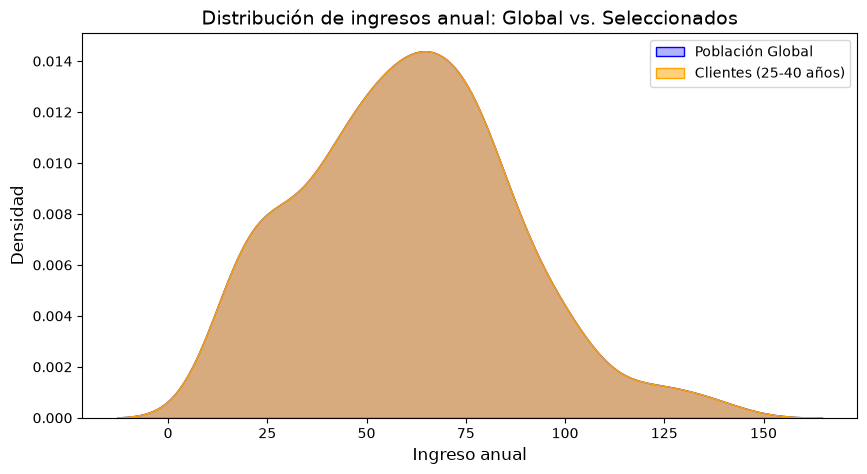

In [60]:
# Grafico 1: Distribución del ingreso anual 
plt.figure(figsize=(10,5))

# Superponemos la distribución global (data)
sns.kdeplot(data=data['Annual Income'],
            label='Población Global',
            fill=True, color='blue', alpha=0.3)

# Superponemos la distribución de los clientes de 25 a 40 años
sns.kdeplot(data=data['Annual Income'],
            label='Clientes (25-40 años)',
            fill=True, color='orange', alpha=0.5)

plt.title('Distribución de ingresos anual: Global vs. Seleccionados', fontsize=14)
plt.xlabel('Ingreso anual', fontsize=12)
plt.ylabel('Densidad', fontsize=12)
plt.legend() # Muestras etiquetadas
plt.show()


<Figure size 1000x500 with 0 Axes>

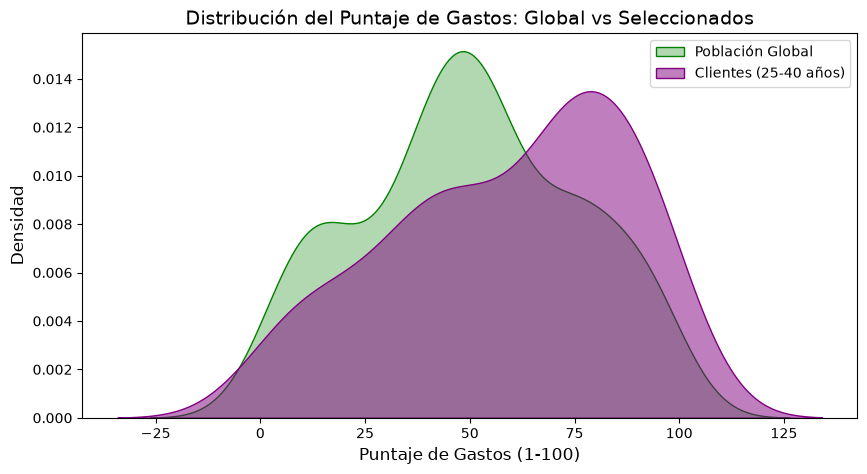

In [61]:
# Grafico 2: Distribución del puntaje de gastos
plt.figure(figsize=(10,5))

plt.figure(figsize=(10, 5))

# Superponemos la distribución global (data)
sns.kdeplot(data=data['Spending Score'], 
            label='Población Global', 
            fill=True, color='green', alpha=0.3)

# Superponemos la distribución de los clientes de 25 a 40 años
sns.kdeplot(data=clientes_seleccionados['Spending Score'], 
            label='Clientes (25-40 años)', 
            fill=True, color='purple', alpha=0.5)

plt.title('Distribución del Puntaje de Gastos: Global vs Seleccionados', fontsize=14)
plt.xlabel('Puntaje de Gastos (1-100)', fontsize=12)
plt.ylabel('Densidad', fontsize=12)
plt.legend()
plt.show()

🤔 &nbsp; **_¿Existe una correlación entre el sueldo anual y el puntaje de gastos en los clientes seleccionados? ¿Y en todos los clientes en general?_**

Correlación global (Sueldo vs Gastos): -0.066
Correlación clientes 25-40 años (Sueldo vs Gastos): 0.050


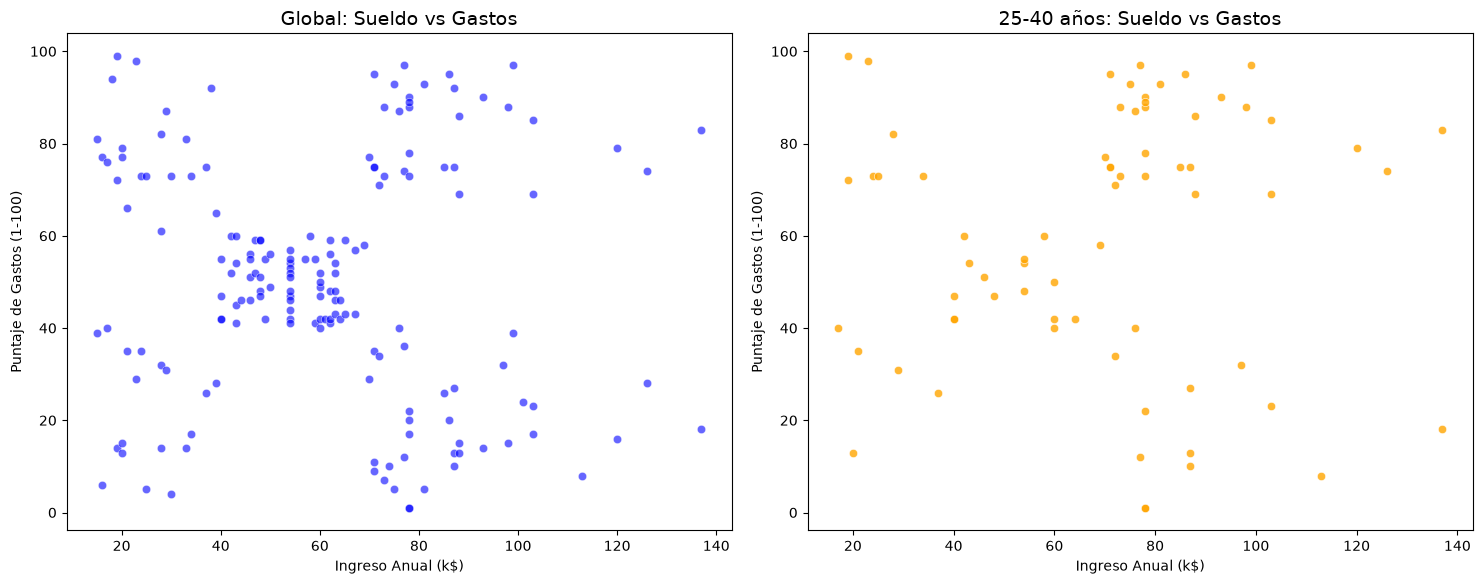

In [ ]:
# 1 Cálculo analítico de la correlación

# Correlación en TODOS los clientes
corr_global = data['Annual Income'].corr(data['Spending Score'])
print(f"Correlación global (Sueldo vs Gastos): {corr_global:.3f}")

# Correlación en los clientes SELECCIONADOS (25 a 40 años)
corr_seleccionados = clientes_seleccionados['Annual Income'].corr(clientes_seleccionados['Spending Score'])
print(f"Correlación clientes 25-40 años (Sueldo vs Gastos): {corr_seleccionados:.3f}")

# 2 Visualización con Gráficos de Dispersión (Scatter Plots)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.set_theme(style="whitegrid")

# Gráfico A: Población Global
# Usamos sns.scatterplot para ver los puntos y sns.regplot si queremos ver la línea de tendencia
sns.scatterplot(
    data=data, 
    x='Annual Income', 
    y='Spending Score', 
    ax=axes[0], 
    color='blue',
    alpha=0.6
)
axes[0].set_title('Global: Sueldo vs Gastos', fontsize=14)
axes[0].set_xlabel('Ingreso Anual (k$)')
axes[0].set_ylabel('Puntaje de Gastos (1-100)')

# Gráfico B: Clientes Seleccionados (25 a 40 años)
sns.scatterplot(
    data=clientes_seleccionados, 
    x='Annual Income', 
    y='Spending Score', 
    ax=axes[1], 
    color='orange',
    alpha=0.8
)
axes[1].set_title('25-40 años: Sueldo vs Gastos', fontsize=14)
axes[1].set_xlabel('Ingreso Anual (k$)')
axes[1].set_ylabel('Puntaje de Gastos (1-100)')

plt.tight_layout()
plt.show()

**_Visualiza otros datos que creas relevantes para este analisis._**

In [ ]:
# Gráfico 1: Mapa de Calor (Heatmap) de Correlaciones

# Primero filtramos solo las variables numéricas y quitamos el ID (no aporta estadísticamente)
columnas_numericas = data.select_dtypes(include=[np.number])
columnas_numericas = columnas_numericas.drop(columns=['CustomerID', 'Unnamed: 0'], errors='ignore')

# Generamos la matriz de correlación
matriz_corr = columnas_numericas.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Mapa de Calor de Correlaciones Globales', fontsize=14)
plt.show()

In [ ]:
# Gráfico 2: Pairplot multivariable segmentado por Género

# Seleccionamos las columnas útiles para no graficar el CustomerID
columnas_grafico = ['Genre', 'Age', 'Annual Income', 'Spending Score']
datos_limpios = data[columnas_grafico].dropna() # Aseguramos no tener nulos

# Generamos el gráfico de pares
sns.pairplot(datos_limpios, hue='Genre', palette='Set1', corner=True)
plt.suptitle('Relaciones Multivariables coloreadas por Género', y=1.02, fontsize=16)
plt.show()

#### 💾 &nbsp; GUARDANDO EL ARCHIVO PARA LOS SIGUIENTES PASOS

Los siguientes pasos que vamos a tomar implican la transformación de los datos presentes en el dataset para un correcto ajuste de un modelo a elección. Para no tener que correr nuevamente todo el código, podemos guardar en un archivo `csv` el dataset tal cual lo tenemos ahora.

1) **Utiliza la función `.to_csv()` para guardar tu dataset**. Antes de hacerlo chequea la [documentación](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.to_csv.html).

In [69]:
# Guardamos el dataset global limpio en tu directorio actual
data.to_csv('/home/leaolarte/Curso_YPF_Data_Science/DataSets/Creado_Datasets/clientes_mall_limpio.csv', index=False)

# Guardamos el dataset segmentado (25 a 40 años) en tu directorio actual
clientes_seleccionados.to_csv('/home/leaolarte/Curso_YPF_Data_Science/DataSets/Creado_Datasets/clientes_seleccionados_25_40.csv', index=False)

print("¡Archivos exportados exitosamente a tu carpeta local!")

¡Archivos exportados exitosamente a tu carpeta local!
